# Επίδραση της ποιότητας δεδομένων στην ανίχνευση ανωμαλιών σε δεδομένα επιχειρησιακών διαδικασιών

# Στόχος:
- Ανάλυση της επιρροής της υποβάθμισης στην απόδοση της ανίχνευσης ανωμαλιών
- Σύγκριση μεθόδων σε περιπτώσεις υποβάθμισης διαφορετικών διαστάσεων ποιότητας
- Εντοπισμός μοτίβων ευρωστίας

In [1]:
import json
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Φόρτωση αποτελεσμάτων από βασικό πείραμα (0% υποβάθμιση) και πείραμα με υποβαθμισμένα δεδομένα (10-20-30%)

In [2]:
def load_results(path_pattern):
    files = glob.glob(path_pattern)
    return [json.load(open(f)) for f in files]

baseline_results = load_results("../results/baseline/*.json")
degradation_results = load_results("../results/degradation/*.json")

print(f"Loaded {len(baseline_results)} baseline runs")
print(f"Loaded {len(degradation_results)} degradation runs")

Loaded 5 baseline runs
Loaded 60 degradation runs


# Ενσωμάτωση τους σε ένα ενιαίο dataframe

In [3]:
def build_dataframe(results):
    rows = []

    for r in results:
        config = r.get("config") or {}

        dimension = config.get("dimension", "baseline")
        level = config.get("level", 0.0)
        seed = config.get("seed", None)

        for detector, metrics in r["overall_metrics"].items():
            rows.append({
                "dimension": dimension,
                "level": level,
                "seed": seed,
                "detector": detector,
                "precision": metrics["precision"],
                "recall": metrics["recall"],
                "f1": metrics["f1"],
            })

    return pd.DataFrame(rows)


df_base = build_dataframe(baseline_results)
df_deg = build_dataframe(degradation_results)

# Baseline expanded as 0% degradation for every degradation dimension
dimensions = df_deg["dimension"].unique()

baseline_expanded = []

for dim in dimensions:
    temp = df_base.copy()
    temp["dimension"] = dim
    temp["level"] = 0.0
    baseline_expanded.append(temp)

df_plot = pd.concat([df_deg] + baseline_expanded, ignore_index=True)

df_plot.head()

,dimension,level,seed,detector,precision,recall,f1
0,accuracy,0.1,42,knn,0.892256,0.736111,0.806697
1,accuracy,0.1,42,lof,0.527066,0.513889,0.520394
2,accuracy,0.1,42,iforest,0.776515,0.569444,0.657051
3,accuracy,0.1,42,dbscan,0.827381,0.772222,0.798851
4,accuracy,0.1,43,knn,0.870861,0.730556,0.794562


# Υπολογισμός μέσης τιμής (mean) και τυπικής απόκλισης (std) για κάθε μετρική

In [4]:
agg_plot = df_plot.groupby(
    ["dimension", "level", "detector"]
).agg(
    precision_mean=("precision", "mean"),
    precision_std=("precision", "std"),
    recall_mean=("recall", "mean"),
    recall_std=("recall", "std"),
    f1_mean=("f1", "mean"),
    f1_std=("f1", "std"),
).reset_index()

agg_plot.head()

,dimension,level,detector,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,accuracy,0.0,dbscan,0.828874,0.021537,0.780000,0.038560,0.802914,0.014423
1,accuracy,0.0,iforest,0.722495,0.032841,0.581111,0.040702,0.643493,0.030806
2,accuracy,0.0,knn,0.885242,0.015557,0.729444,0.026687,0.799449,0.013537
3,accuracy,0.0,lof,0.528396,0.027591,0.465556,0.036935,0.494482,0.029362
4,accuracy,0.1,dbscan,0.826931,0.023694,0.782222,0.036250,0.803205,0.013670


In [5]:
baseline = df_base.groupby(
    ["detector"]
).agg(
    precision_mean=("precision", "mean"),
    precision_std=("precision", "std"),
    recall_mean=("recall", "mean"),
    recall_std=("recall", "std"),
    f1_mean=("f1", "mean"),
    f1_std=("f1", "std"),
).reset_index()

display(baseline)

,detector,precision_mean,precision_std,recall_mean,recall_std,f1_mean,f1_std
0,dbscan,0.828874,0.021537,0.780000,0.038560,0.802914,0.014423
1,iforest,0.722495,0.032841,0.581111,0.040702,0.643493,0.030806
2,knn,0.885242,0.015557,0.729444,0.026687,0.799449,0.013537
3,lof,0.528396,0.027591,0.465556,0.036935,0.494482,0.029362


# Η υποβάθμιση σε ποιες διαστάσεις ποιότητας έχει την μεγαλύτερη επιρροή στην απόδοση (F1);

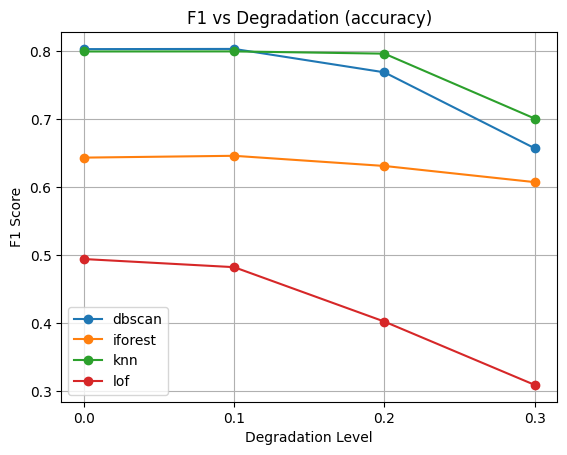

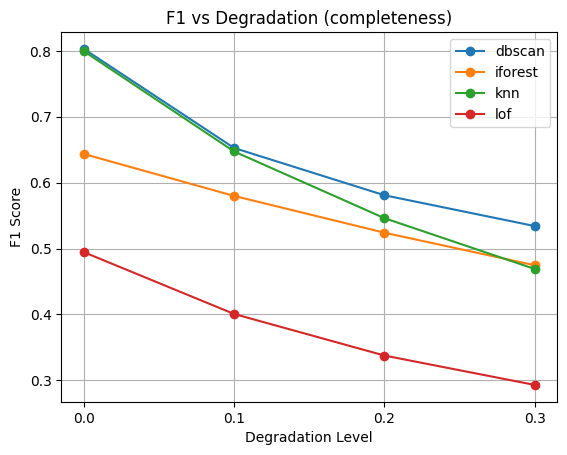

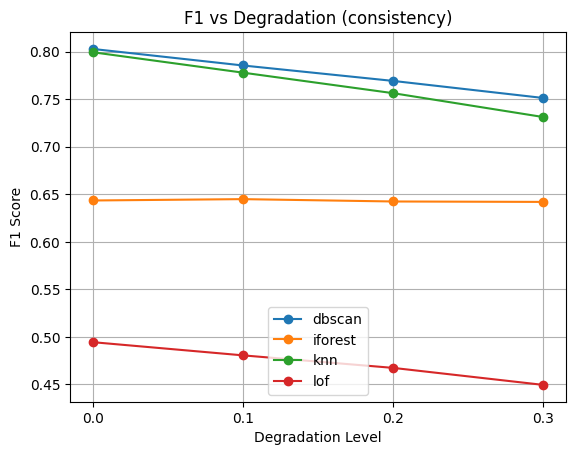

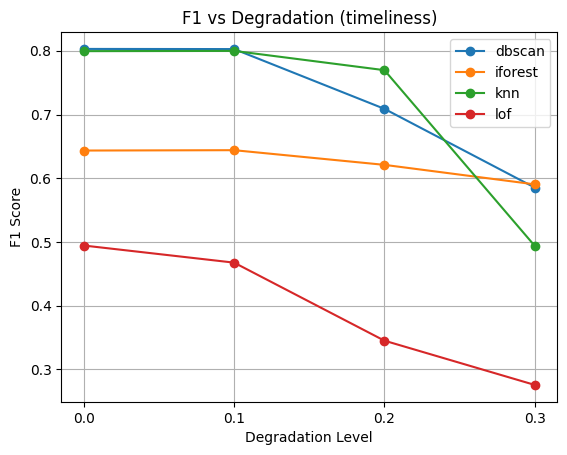

In [6]:
for dim in df_deg["dimension"].unique():
    subset = agg_plot[agg_plot["dimension"] == dim]

    plt.figure()

    for detector in subset["detector"].unique():
        d = subset[subset["detector"] == detector].sort_values("level")

        plt.plot(
            d["level"],
            d["f1_mean"],
            marker="o",
            label=detector
        )

    plt.title(f"F1 vs Degradation ({dim})")
    plt.xlabel("Degradation Level")
    plt.ylabel("F1 Score")
    plt.xticks([0.0, 0.1, 0.2, 0.3])
    plt.legend()
    plt.grid()
    plt.show()

## Παρατήρηση:
Η τιμή της μετρικής F1 γενικά μειώνεται όσο αυξάνεται η υποβάθμιση της ποιότητας, αποδεικνύοντας ότι η υποβάθμιση της ποιότητας μειώνει γενικά την αξιοπιστία κάθε μεθόδου.

# Ανάκληση: Πώς επηρεάζεται ο αριθμός των false negatives από την υποβάθμιση της ποιότητας;

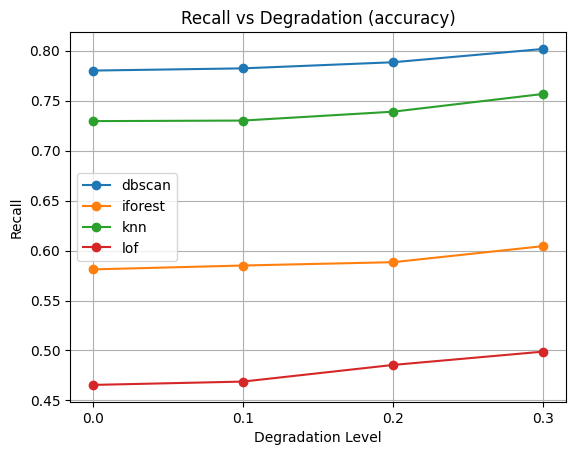

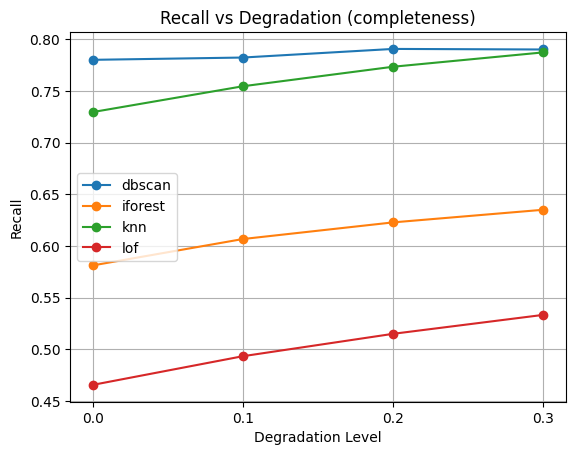

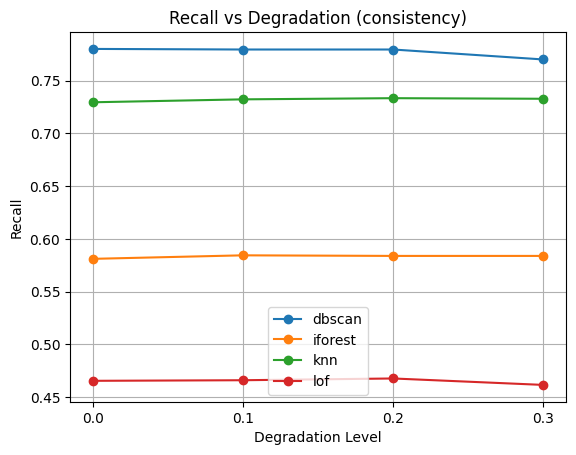

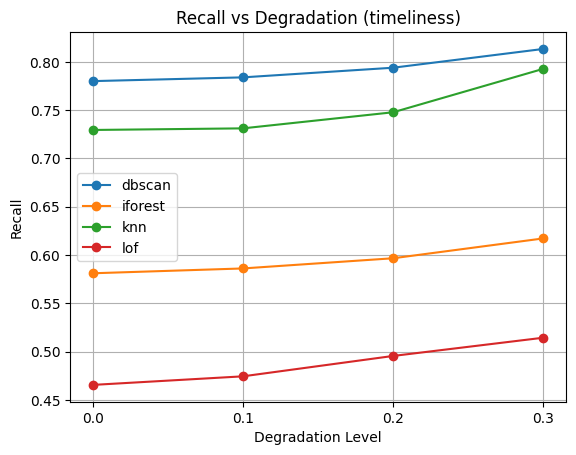

In [7]:
for dim in df_deg["dimension"].unique():
    subset = agg_plot[agg_plot["dimension"] == dim]

    plt.figure()

    for detector in subset["detector"].unique():
        d = subset[subset["detector"] == detector].sort_values("level")

        plt.plot(
            d["level"],
            d["recall_mean"],
            marker="o",
            label=detector
        )

    plt.title(f"Recall vs Degradation ({dim})")
    plt.xlabel("Degradation Level")
    plt.ylabel("Recall")
    plt.xticks([0.0, 0.1, 0.2, 0.3])
    plt.legend()
    plt.grid()
    plt.show()
    plt.show()

## Παρατήρηση:
Η ανάκληση **αυξάνεται** υπό συνθήκες σταδιακής υποβάθμισης. Αυτό δείχνει ότι αυξάνεται η αυστηρότητα των ανιχνευτών

# Ακρίβεια (Precision): ο λόγος για τον οποίο η γενικότερη απόδοση (F1) μειώνεται παρά την μείωση της ανάκλησης και των false negatives.

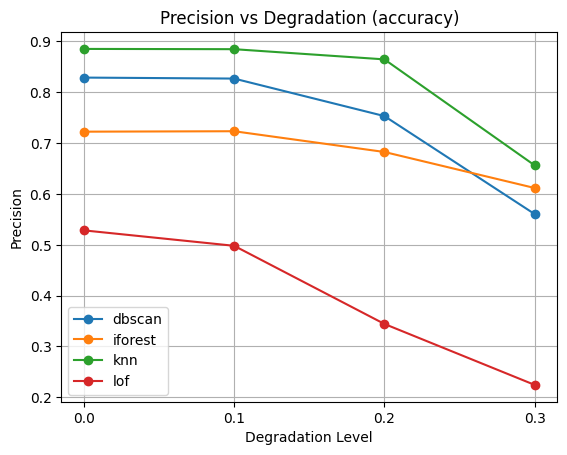

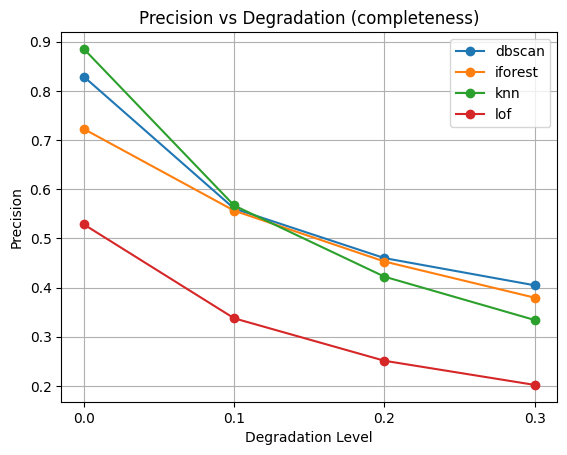

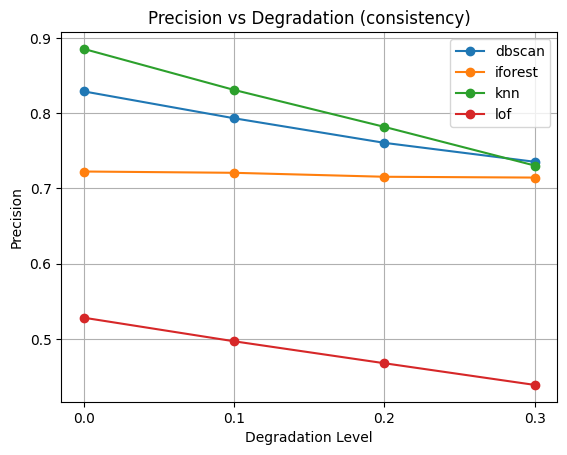

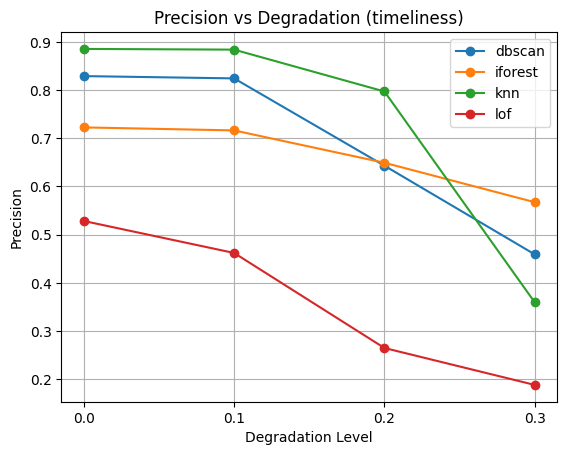

In [8]:
for dim in df_deg["dimension"].unique():
    subset = agg_plot[agg_plot["dimension"] == dim]

    plt.figure()

    for detector in subset["detector"].unique():
        d = subset[subset["detector"] == detector].sort_values("level")

        plt.plot(
            d["level"],
            d["precision_mean"],
            marker="o",
            label=detector
        )

    plt.title(f"Precision vs Degradation ({dim})")
    plt.xlabel("Degradation Level")
    plt.ylabel("Precision")
    plt.xticks([0.0, 0.1, 0.2, 0.3])
    plt.legend()
    plt.grid()
    plt.show()

## Εξήγηση
Η ακρίβεια **μειώνεται** όσο αυξάνεται η υποβάθμιση της ποιότητας, επιβεβαιώνοντας ότι η μείωση των false negatives έχει κόστος την **ραγδαία** αύξηση των false positives. Αυτό εξηγεί την μείωση της μετρικής F1, παρά την αυξημένη "επιθετικότητα" των μοντέλων.

# Ρυθμός αύξησης των false positives:

In [9]:
def build_confusion_df(results):
    rows = []

    for r in results:
        config = r.get("config") or {}

        dimension = config.get("dimension", "baseline")
        level = config.get("level", 0.0)
        seed = config.get("seed", None)

        for detector, metrics in r["overall_metrics"].items():
            cm = metrics["confusion_matrix"]

            tn, fp = cm[0]
            fn, tp = cm[1]

            fpr = fp / (fp + tn) if (fp + tn) else 0.0

            rows.append({
                "dimension": dimension,
                "level": level,
                "seed": seed,
                "detector": detector,
                "tn": tn,
                "fp": fp,
                "fn": fn,
                "tp": tp,
                "fpr": fpr,
            })

    return pd.DataFrame(rows)

In [10]:
cm_base = build_confusion_df(baseline_results)
cm_deg = build_confusion_df(degradation_results)

dimensions = cm_deg["dimension"].unique()

baseline_expanded = []

for dim in dimensions:
    temp = cm_base.copy()
    temp["dimension"] = dim
    temp["level"] = 0.0
    baseline_expanded.append(temp)

cm_plot_df = pd.concat([cm_deg] + baseline_expanded, ignore_index=True)

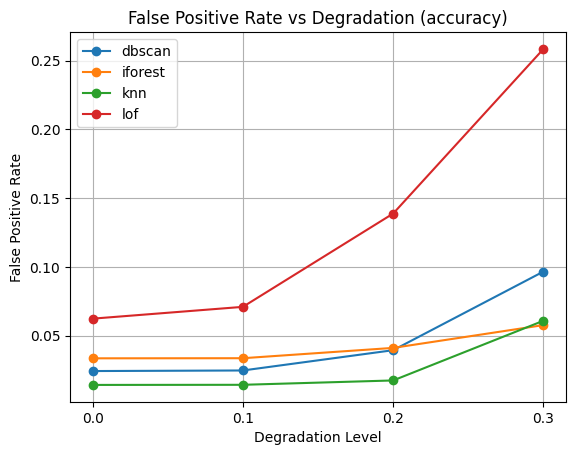

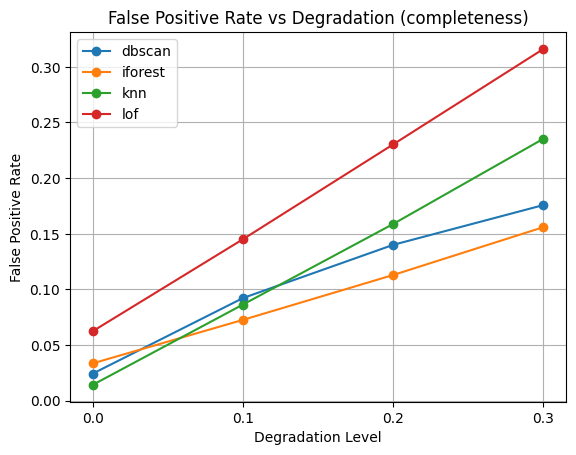

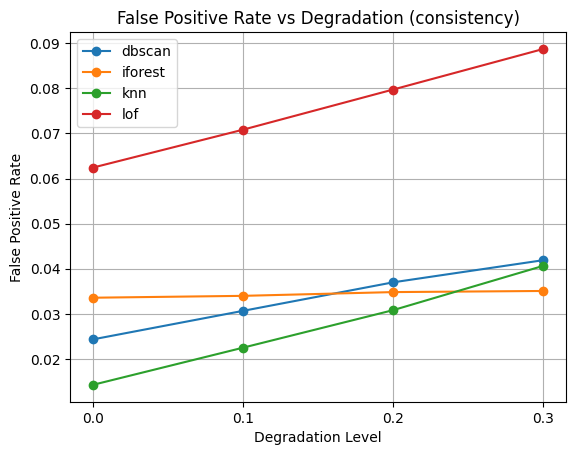

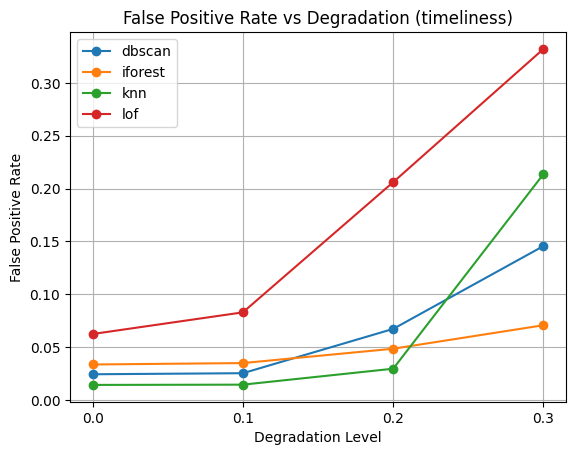

In [11]:
cm_agg = cm_plot_df.groupby(
    ["dimension", "level", "detector"]
).agg(
    fpr_mean=("fpr", "mean"),
    fpr_std=("fpr", "std"),
    fp_mean=("fp", "mean"),
    tp_mean=("tp", "mean"),
).reset_index()

for dim in cm_deg["dimension"].unique():
    subset = cm_agg[cm_agg["dimension"] == dim]

    plt.figure()

    for detector in subset["detector"].unique():
        d = subset[subset["detector"] == detector].sort_values("level")

        plt.plot(
            d["level"],
            d["fpr_mean"],
            marker="o",
            label=detector
        )

    plt.title(f"False Positive Rate vs Degradation ({dim})")
    plt.xlabel("Degradation Level")
    plt.ylabel("False Positive Rate")
    plt.xticks([0.0, 0.1, 0.2, 0.3])
    plt.legend()
    plt.grid()
    plt.show()

## Ερμηνεία
Η αύξηση της ανάκλησης των μοντέλων προκύπτει από ταυτόχρονη ραγδαία αύξηση των false positives. Επομένως, η ύπαρξη προβλημάτων ποιότητας δεδομένων κάνει τους ανιχνευτές πιο **αυστηρούς**, όχι απαραίτητα πιο **αξιόπιστους** όμως.

# Μεταβολή του F1 score: η μείωση της ποιότητας σε ποιά διάσταση της προκαλεί την μεγαλύτερη ζημιά;

In [12]:
baseline_f1 = baseline.set_index("detector")["f1_mean"]

delta_rows = []

for _, row in agg_plot.iterrows():
    detector = row["detector"]
    base = baseline_f1[detector]

    delta_rows.append({
        "dimension": row["dimension"],
        "level": row["level"],
        "detector": detector,
        "delta_f1": row["f1_mean"] - base,
    })

delta_df = pd.DataFrame(delta_rows)
delta_df.head()

,dimension,level,detector,delta_f1
0,accuracy,0.0,dbscan,0.000000
1,accuracy,0.0,iforest,0.000000
2,accuracy,0.0,knn,0.000000
3,accuracy,0.0,lof,0.000000
4,accuracy,0.1,dbscan,0.000291


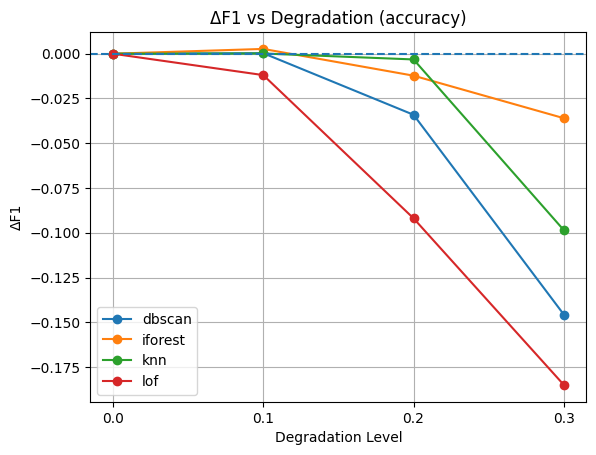

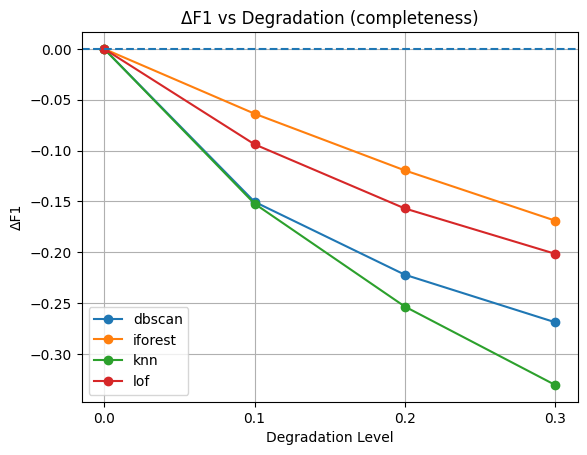

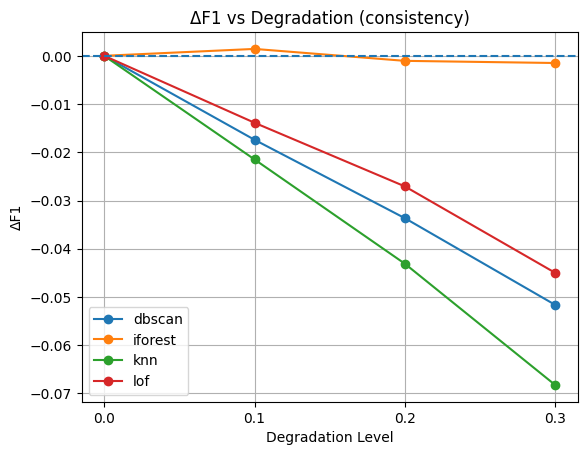

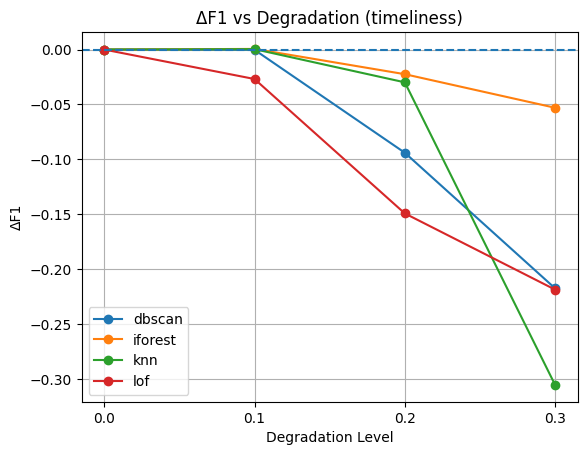

In [13]:
for dim in delta_df["dimension"].unique():
    subset = delta_df[delta_df["dimension"] == dim]

    plt.figure()

    for detector in subset["detector"].unique():
        d = subset[subset["detector"] == detector].sort_values("level")

        plt.plot(
            d["level"],
            d["delta_f1"],
            marker="o",
            label=detector
        )

    plt.axhline(0, linestyle="--")
    plt.title(f"ΔF1 vs Degradation ({dim})")
    plt.xlabel("Degradation Level")
    plt.ylabel("ΔF1")
    plt.xticks([0.0, 0.1, 0.2, 0.3])
    plt.legend()
    plt.grid()
    plt.show()

## Παρατήρηση
Η μεγαλύτερη πτώση στην απόδοση προκαλείται από υποβάθμιση της πληρότητας. Η συνέπεια έχει την χαμηλότερη επιρροή στην απόδοση. Η ακρίβεια επηρεάζει παρόμοια όλους τους ανιχνευτές, ενώ η επικαιρότητα επηρεάζει κυρίως μεθόδους βασισμένες στην απόσταση (K-NN).

## Ανάλυση ανά τύπο ανωμαλιών. Ποιού είδους ανωμαλίες γίνονται λιγότερο (ή περισσότερο) αντιληπτές;

In [14]:
def build_subtype_df(degradation_results, baseline_results):
    rows = []

    # 🔹 Degradation results
    for r in degradation_results:
        config = r["config"]

        for detector, subtypes in r["per_subtype_metrics"].items():
            for subtype, metrics in subtypes.items():
                rows.append({
                    "dimension": config["dimension"],
                    "level": config["level"],
                    "seed": config["seed"],
                    "detector": detector,
                    "subtype": subtype,
                    "recall": metrics["recall"],
                })

    # 🔹 Baseline → expand σε όλα τα dimensions
    dimensions = sorted(
        set(r["config"]["dimension"] for r in degradation_results)
    )

    for r in baseline_results:
        seed = r["config"]["seed"]

        for detector, subtypes in r["per_subtype_metrics"].items():
            for subtype, metrics in subtypes.items():

                for dim in dimensions:
                    rows.append({
                        "dimension": dim,
                        "level": 0.0,
                        "seed": seed,
                        "detector": detector,
                        "subtype": subtype,
                        "recall": metrics["recall"],
                    })

    df = pd.DataFrame(rows)

    # 🔹 safety: types
    df["level"] = df["level"].astype(float)

    return df

subtype_df = build_subtype_df(degradation_results, baseline_results)
subtype_df.head()

,dimension,level,seed,detector,subtype,recall
0,accuracy,0.1,42,knn,contextual_out_of_range,1.000000
1,accuracy,0.1,42,knn,contextual_priority_duration,1.000000
2,accuracy,0.1,42,knn,contextual_wrong_resource,0.530612
3,accuracy,0.1,42,knn,structural_double_end,0.409091
4,accuracy,0.1,42,knn,structural_missing_and_wrong,1.000000


In [15]:
subtype_stats = subtype_df.groupby(
    ["dimension", "level", "detector", "subtype"]
).agg(
    recall_mean=("recall", "mean"),
    recall_std=("recall", "std"),
    support=("recall", "count"),
).reset_index()

subtype_stats.head()

,dimension,level,detector,subtype,recall_mean,recall_std,support
0,accuracy,0.0,dbscan,contextual_out_of_range,1.000000,0.000000,5
1,accuracy,0.0,dbscan,contextual_priority_duration,1.000000,0.000000,5
2,accuracy,0.0,dbscan,contextual_wrong_resource,0.659227,0.100664,5
3,accuracy,0.0,dbscan,structural_double_end,0.700209,0.173371,5
4,accuracy,0.0,dbscan,structural_missing_and_wrong,0.986406,0.018655,5


In [16]:
baseline_recall = (
    subtype_stats[subtype_stats["level"] == 0.0]
    .groupby(["dimension", "detector", "subtype"])["recall_mean"]
    .mean()
)

delta_rows = []

for _, row in subtype_stats.iterrows():
    base = baseline_recall.loc[
        (row["dimension"], row["detector"], row["subtype"])
    ]

    delta_rows.append({
        **row.to_dict(),
        "delta_recall": row["recall_mean"] - base,
    })

delta_subtype_stats = pd.DataFrame(delta_rows)
delta_subtype_stats.head()

,dimension,level,detector,subtype,recall_mean,recall_std,support,delta_recall
0,accuracy,0.0,dbscan,contextual_out_of_range,1.000000,0.000000,5,0.0
1,accuracy,0.0,dbscan,contextual_priority_duration,1.000000,0.000000,5,0.0
2,accuracy,0.0,dbscan,contextual_wrong_resource,0.659227,0.100664,5,0.0
3,accuracy,0.0,dbscan,structural_double_end,0.700209,0.173371,5,0.0
4,accuracy,0.0,dbscan,structural_missing_and_wrong,0.986406,0.018655,5,0.0


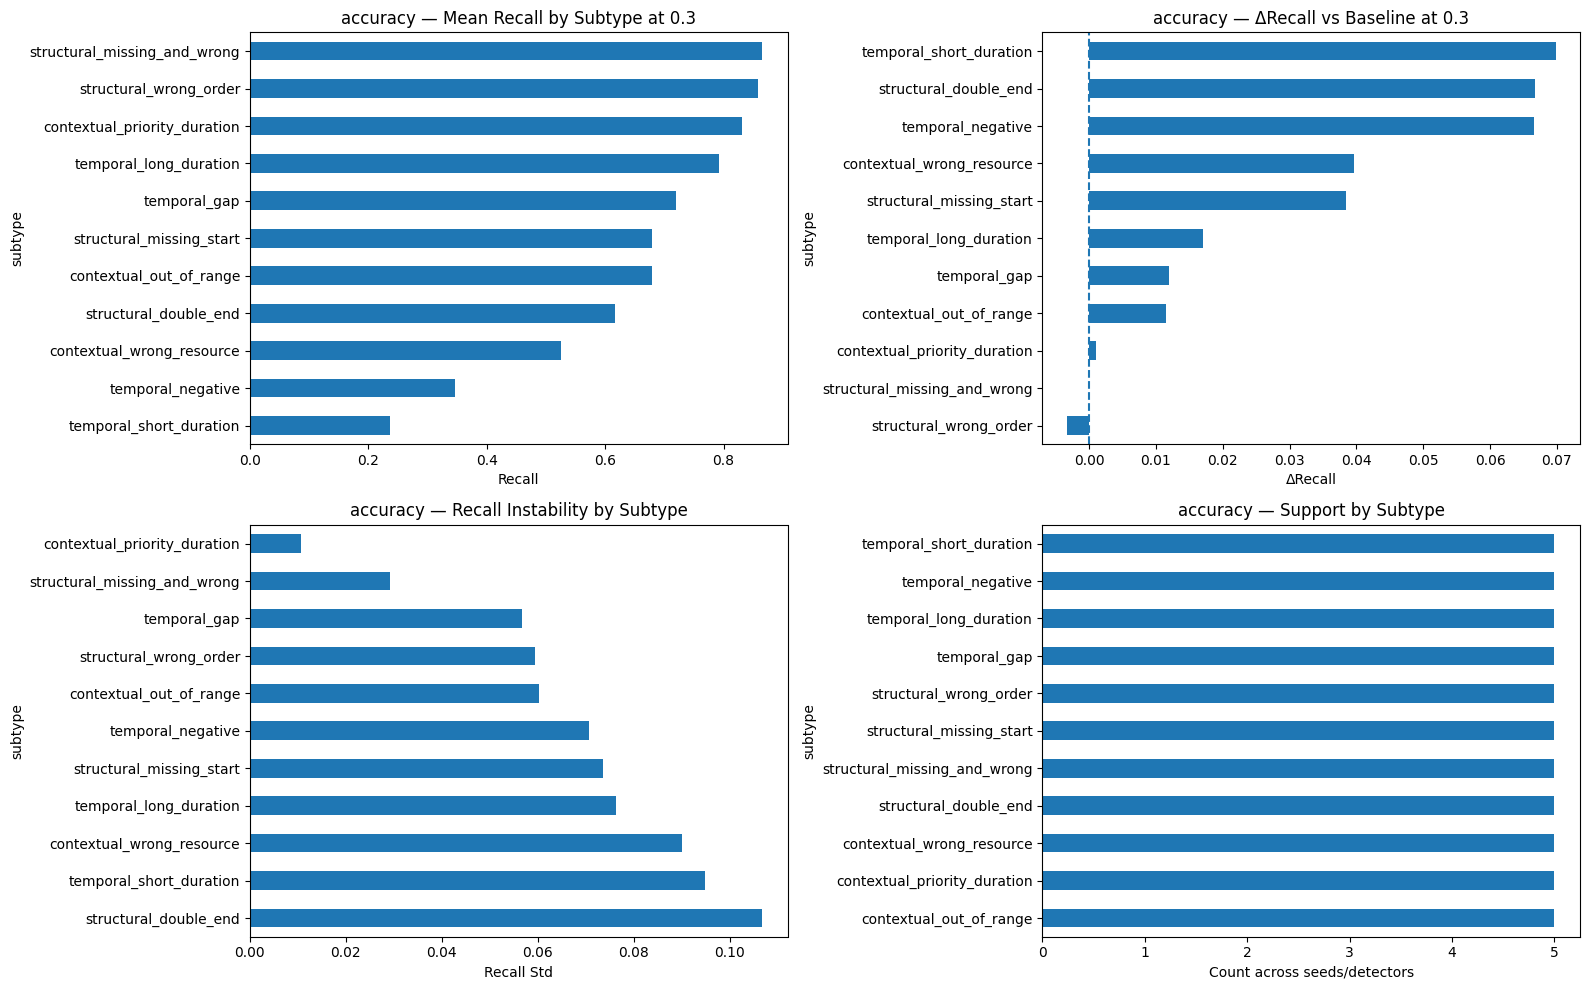

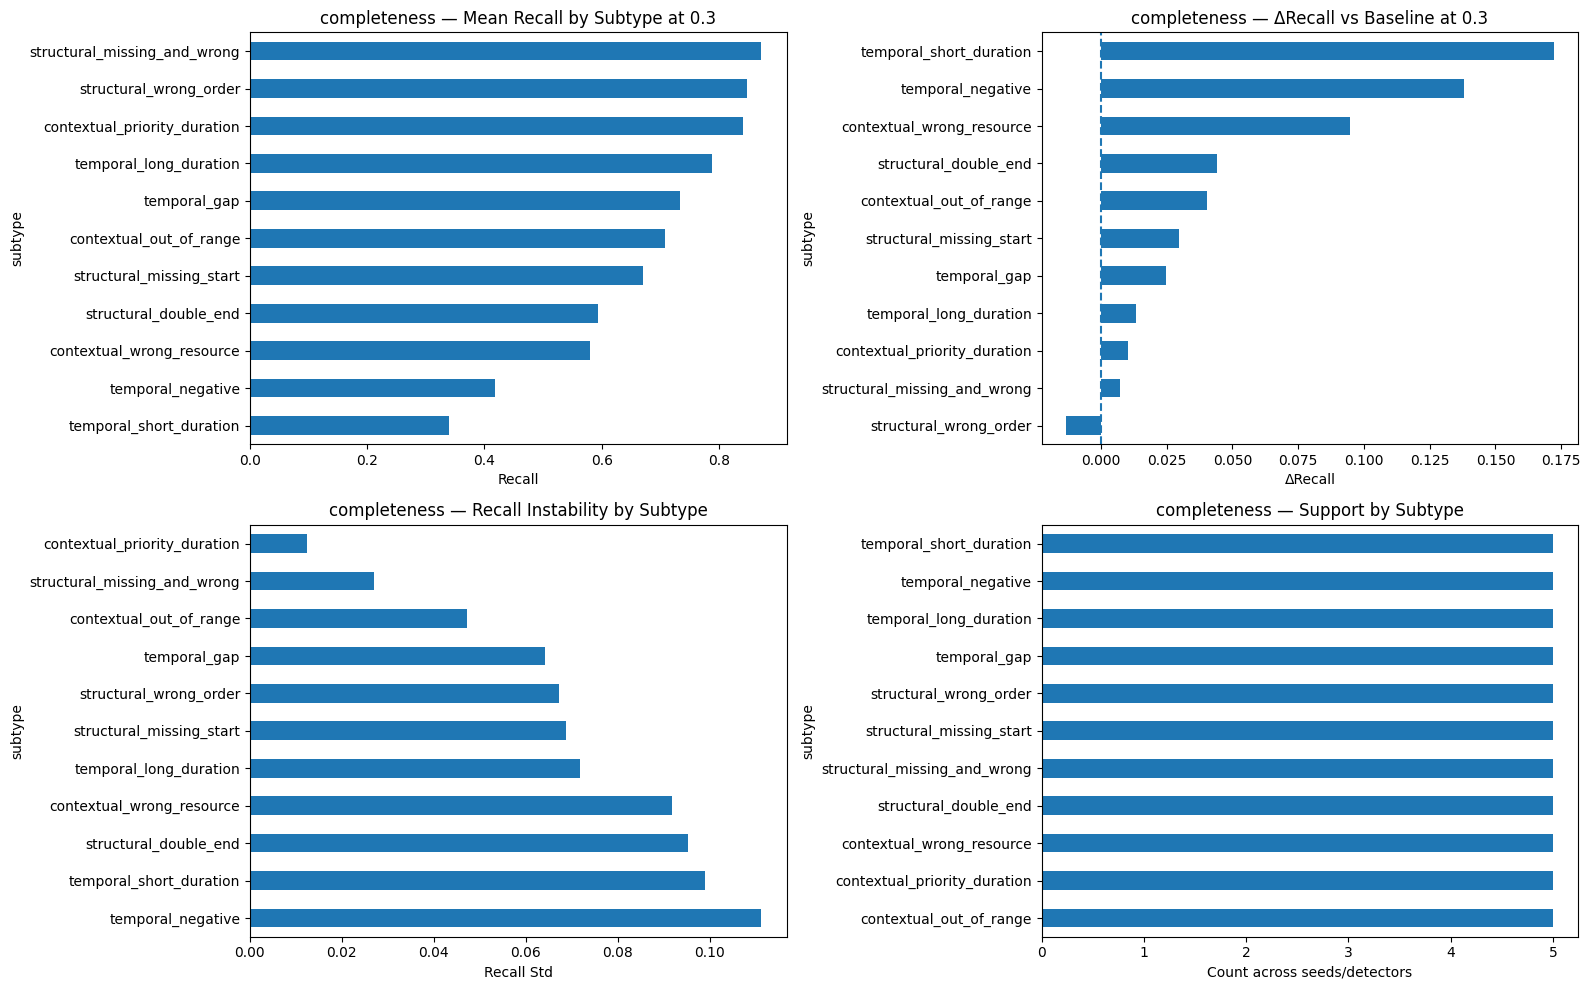

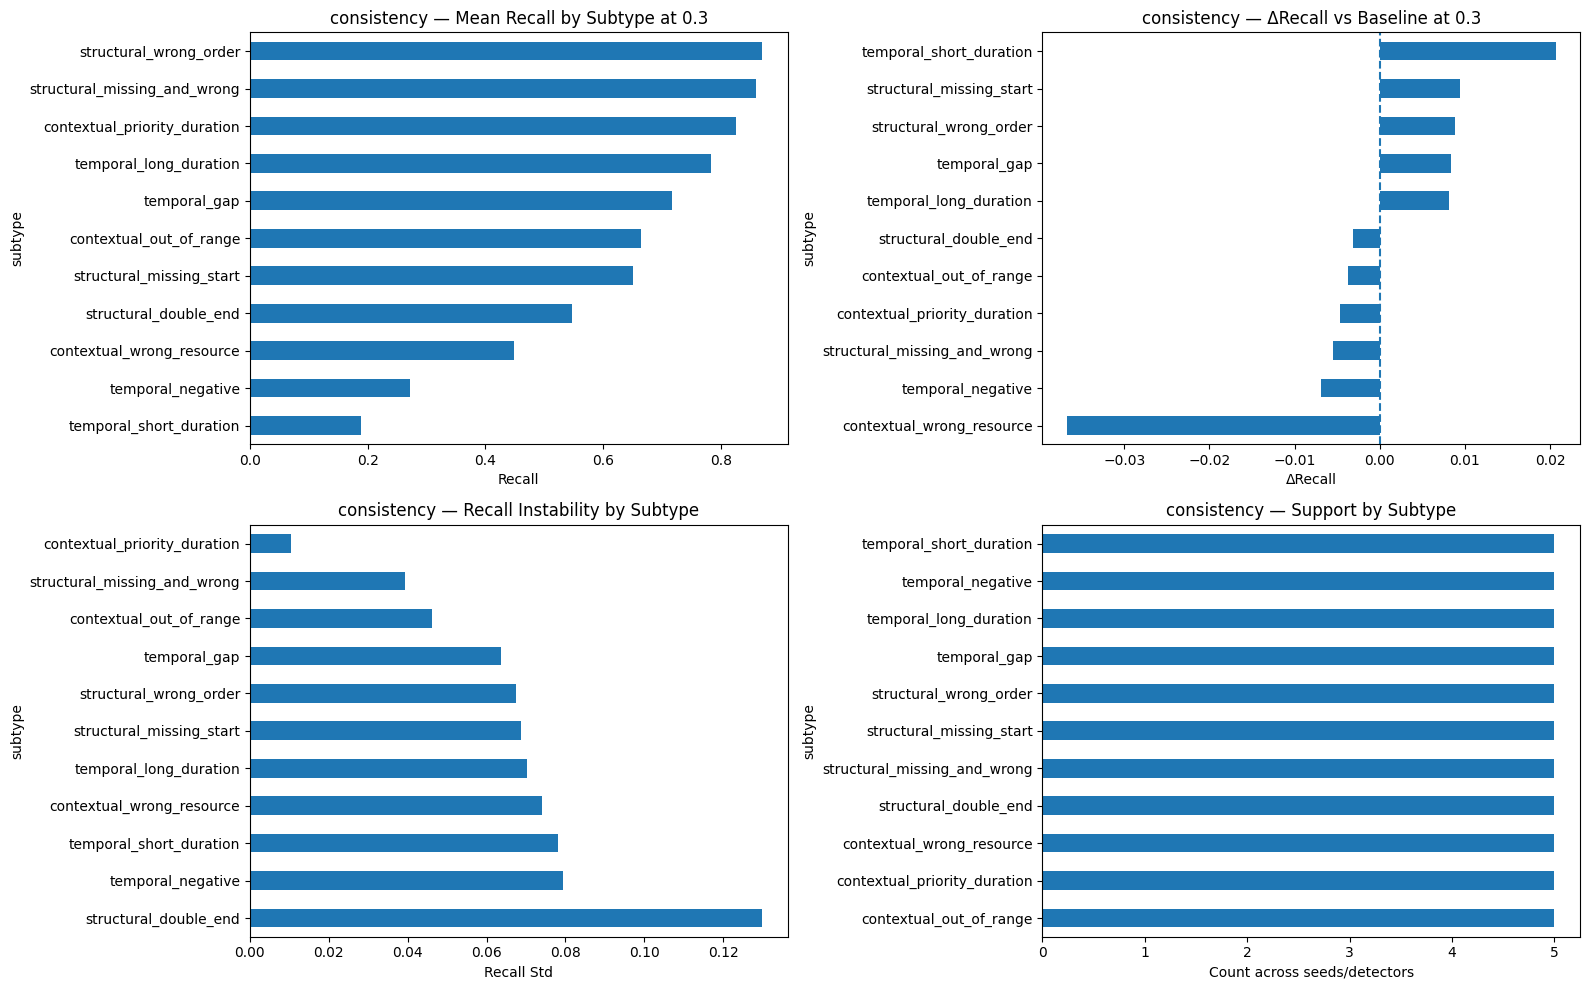

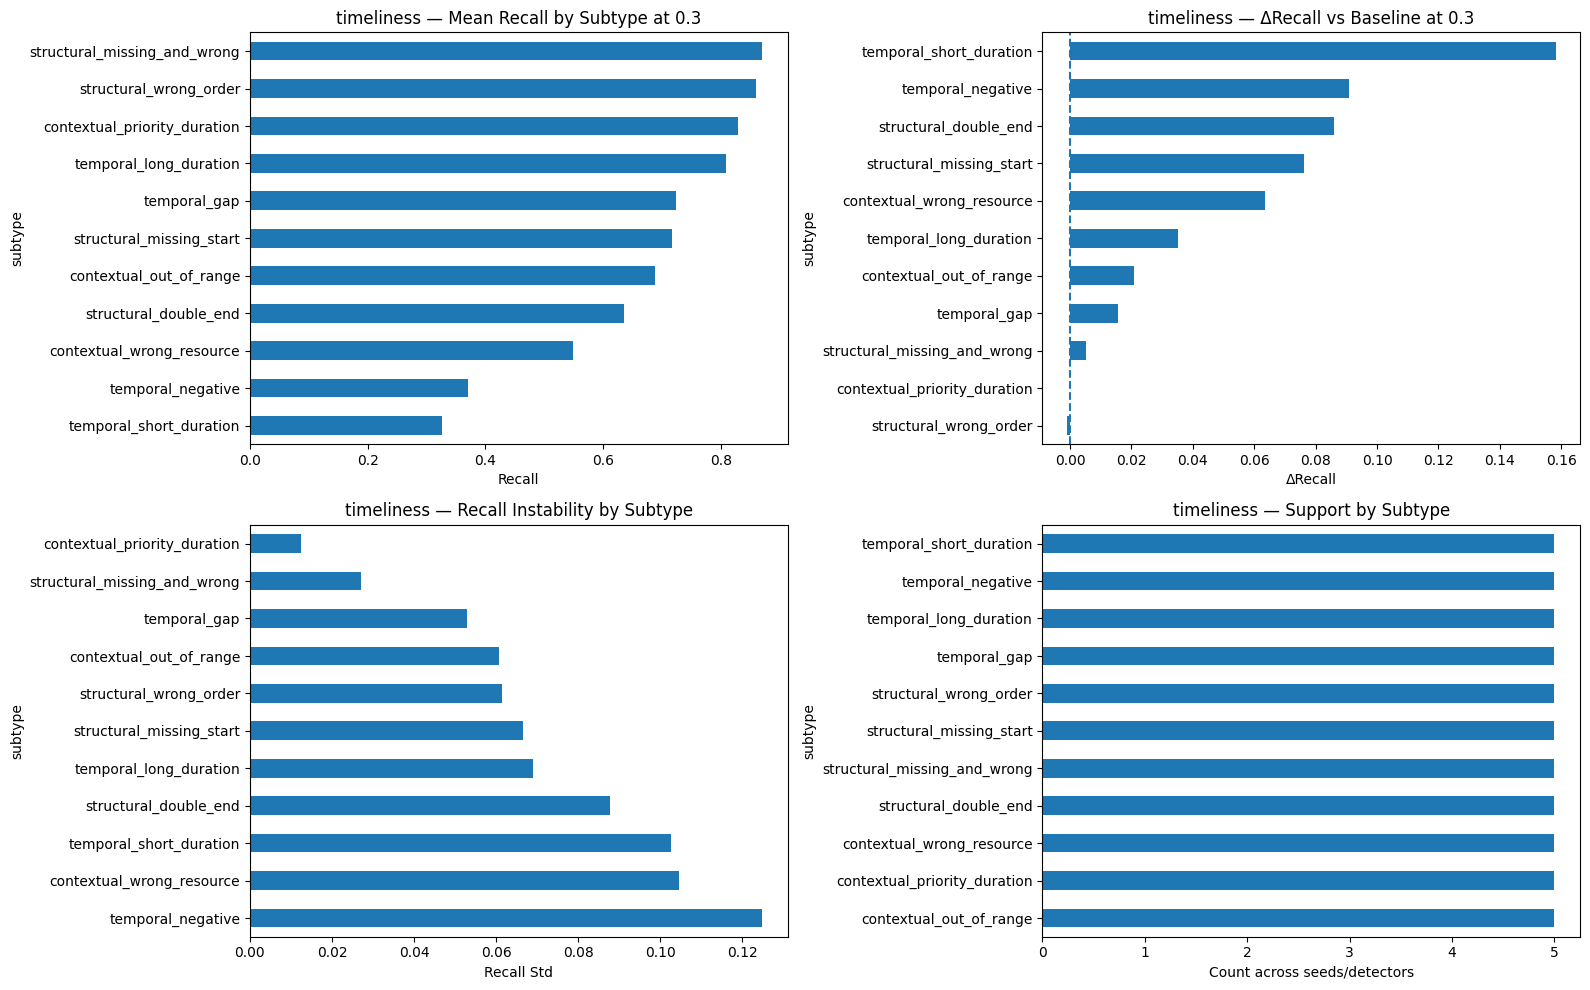

In [17]:
for dim in subtype_stats["dimension"].unique():
    dim_stats = subtype_stats[subtype_stats["dimension"] == dim]
    dim_delta = delta_subtype_stats[delta_subtype_stats["dimension"] == dim]

    latest_level = dim_stats["level"].max()

    latest_stats = dim_stats[dim_stats["level"] == latest_level]
    latest_delta = dim_delta[dim_delta["level"] == latest_level]

    recall_by_subtype = (
        latest_stats.groupby("subtype")["recall_mean"]
        .mean()
        .sort_values()
    )

    delta_by_subtype = (
        latest_delta.groupby("subtype")["delta_recall"]
        .mean()
        .sort_values()
    )

    std_by_subtype = (
        latest_stats.groupby("subtype")["recall_std"]
        .mean()
        .sort_values(ascending=False)
    )

    support_by_subtype = (
        latest_stats.groupby("subtype")["support"]
        .mean()
        .sort_values()
    )

    fig, axes = plt.subplots(2, 2, figsize=(16, 10))

    recall_by_subtype.plot(kind="barh", ax=axes[0, 0])
    axes[0, 0].set_title(f"{dim} — Mean Recall by Subtype at {latest_level:.1f}")
    axes[0, 0].set_xlabel("Recall")

    delta_by_subtype.plot(kind="barh", ax=axes[0, 1])
    axes[0, 1].axvline(0, linestyle="--")
    axes[0, 1].set_title(f"{dim} — ΔRecall vs Baseline at {latest_level:.1f}")
    axes[0, 1].set_xlabel("ΔRecall")

    std_by_subtype.plot(kind="barh", ax=axes[1, 0])
    axes[1, 0].set_title(f"{dim} — Recall Instability by Subtype")
    axes[1, 0].set_xlabel("Recall Std")

    support_by_subtype.plot(kind="barh", ax=axes[1, 1])
    axes[1, 1].set_title(f"{dim} — Support by Subtype")
    axes[1, 1].set_xlabel("Count across seeds/detectors")

    plt.tight_layout()
    plt.show()

### Τι εντοπίζουμε για κάθε υπο-τύπο:

- Η επιρροή της υποβάθμισης της ποιότητας **δεν είναι ισότιμη για κάθε υποτύπο ανωμαλίας**.
- Ορισμένες χρονικές ανωμαλίες (π.χ., *πολύ μικρή διάρκεια δραστηριότητας*, *αρνητική διάρκεια δραστηριότητας*) δείχνουν **υψηλότερη ανάκληση**, υποδεικνύοντας ότι η υποβάθμιση αμβλύνει την απόκλιση τους και διευκολύνει την ανίχνευσή τους.
- Άλλοι υπο-τύποι (π.χ., ανωμαλίες δομής ή πλαισίου) δείχνουν **μηδαμινή ή και αρνητική ΔRecall**, κάτι που σημαίνει ότι ο θόρυβος **αλλοιώνει τα μοτίβα διάκρισης τους**.
- **Η υποβάθμιση στην πληρότητα** οδηγεί στις πιο προφανείς αλλαγές, επηρεάζοντας τόσο την απόδοση όσο και την σταθερότητα των ανιχνευτών, καθώς events που λείπουν διασπούν την δομή ροής ελέγχου.
- **Η υποβάθμιση στην συνέπεια** έχει πιο ήπια επίδραση, επιβεβαιώνοντας ότι αλλαγές στο format των δεδομένων είναι λιγότερο καταστροφικές από δομικές αλλοιώσεις.
- Αυξημένη **διακύμανση στην ανάκληση (std)** για διάφορους υπο-τύπους δείχνει μειωμένη σταθερότητα, που σημαίνει ότι η ανίχνευση ανωμαλιών γίνεται **όλο και πιο αναξιόπιστη από εκτέλεση σε εκτέλεση**.
- Κάθε υπο-τύπος έχει το ίδιο δείγμα υποστήριξης, οπότε τα συγκεκριμένα αποτελέσματα **δεν οφείλονται σε ανισσόροπα δείγματα**, αλλά στην αλληλεπίδραση ανάμεσα στην υποβάθμιση της ποιότητας δεδομένων και την αναπαράσταση χαρακτηριστικών.

> Συνολικά, τα προβλήματα στην ποιότητα δεδομένων μπορούν εξίσου **να αμβλύνουν και να "κρύψουν" πραγματικές ανωμαλίες**, οδηγώντας σε ασταθή συμπεριφορά ανίχνευσης ανάλογα με τον υπο-τύπο.

In [18]:
sensitivity_ranking = (
    delta_subtype_stats[delta_subtype_stats["level"] > 0.0]
    .groupby("subtype")["delta_recall"]
    .mean()
    .sort_values()
    .reset_index()
)

sensitivity_ranking

,subtype,delta_recall
0,structural_missing_and_wrong,-0.000112
1,contextual_priority_duration,0.000577
2,structural_wrong_order,0.001626
3,temporal_gap,0.006844
4,contextual_out_of_range,0.010449
5,temporal_long_duration,0.015593
6,structural_missing_start,0.017665
7,contextual_wrong_resource,0.023698
8,structural_double_end,0.029484
9,temporal_negative,0.045052


In [22]:
detector_subtype_ranking = (
    delta_subtype_stats[delta_subtype_stats["level"] > 0.0]
    .groupby(["detector", "subtype"])["delta_recall"]
    .mean()
    .reset_index()
    .sort_values(["detector", "delta_recall"])
)

from IPython.display import display

detectors = detector_subtype_ranking["detector"].unique()

tables = []

for d in detectors:
    df = (
        detector_subtype_ranking[
            detector_subtype_ranking["detector"] == d
        ][["subtype", "delta_recall"]]
        .sort_values("delta_recall")
        .reset_index(drop=True)
        .rename(columns={"delta_recall": d})
    )

    tables.append(df.set_index("subtype"))

# combine side-by-side
combined = pd.concat(tables, axis=1)

display(combined)

,dbscan,iforest,knn,lof
subtype,,,,
structural_missing_start,-0.012242,0.029405,0.025032,0.028464
temporal_gap,-0.004586,-0.003413,0.016614,0.018762
structural_wrong_order,-0.003787,0.010360,-0.005716,0.005646
contextual_out_of_range,0.000000,0.032514,0.001351,0.007932
contextual_priority_duration,0.000000,0.000000,0.000000,0.002309
contextual_wrong_resource,0.000472,0.034629,0.030619,0.029071
structural_missing_and_wrong,0.001613,0.000242,0.001613,-0.003915
temporal_long_duration,0.011002,0.012553,0.014965,0.023851
structural_double_end,0.019868,0.033596,0.040952,0.023519


# Στατιστική σημαντικότητα

In [24]:
from scipy.stats import ttest_rel

def compare_baseline_vs_degradation(df_plot, detector, level=0.3):
    base = df_plot[
        (df_plot["level"] == 0.0) &
        (df_plot["detector"] == detector)
    ]["f1"]

    deg = df_plot[
        (df_plot["level"] == level) &
        (df_plot["detector"] == detector)
    ]["f1"]

    stat, p = ttest_rel(base, deg)

    return {"detector": detector, "t_stat": stat, "p_value": p}


for d in df_plot["detector"].unique():
    print(compare_baseline_vs_degradation(df_plot, d))

{'detector': 'knn', 't_stat': np.float64(7.2997573244006), 'p_value': np.float64(6.354457430518387e-07)}
{'detector': 'lof', 't_stat': np.float64(10.140613076737429), 'p_value': np.float64(4.200922224377754e-09)}
{'detector': 'iforest', 't_stat': np.float64(4.443301754942532), 'p_value': np.float64(0.0002788727012784006)}
{'detector': 'dbscan', 't_stat': np.float64(8.786144557294278), 'p_value': np.float64(4.053434127992712e-08)}


# Τι παρατηρούμε:
Η πτώση της απόδοσης που εντοπίσαμε είναι στατιστικά σημαντική σε όλους τους ανιχνευτές (p < 0.001), επιβεβαιώνοντας ότι η επίδραση των προβλημάτων ποιότητας είναι συστηματική και όχι τυχαία.

# Κατάταξη μεθόδων βάσει ευρωστίας

In [25]:
robustness = (
    delta_df[delta_df["level"] > 0.0]
    .groupby("detector")["delta_f1"]
    .mean()
    .sort_values()
)

robustness

detector
knn       -0.108792
dbscan    -0.102936
lof       -0.101815
iforest   -0.039474
Name: delta_f1, dtype: float64

# Επεξήγηση:
Το Isolation Forest είναι η πιο εύρωστη μέθοδος σε συνθήκες υποβαθμισμένης ποιότητας δεδομένων, όντας όμως η λιγότερο αποδοτική σε περιβάλλον χωρίς προβλήματα. Από την άλλη, οι KNN και DBSCAN επιτυγχάνουν υψηλότερη απόδοση αρχικά αλλά είναι πιο ευαίσθητοι σε προβλήματα ποιότητας δεδομένων.

# Trade-off μεταξύ ακρίβειας και ανάκλησης

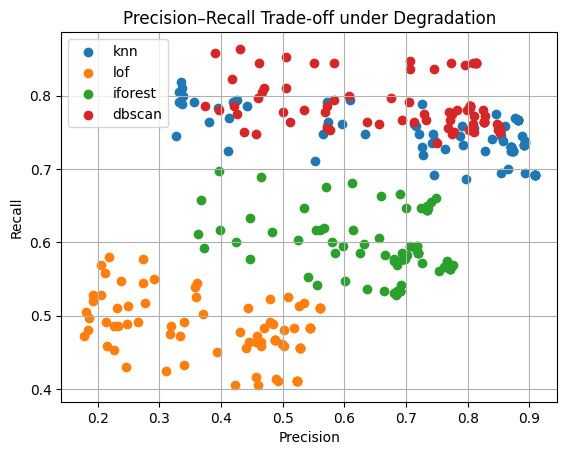

In [26]:
plt.figure()

for d in df_plot["detector"].unique():
    subset = df_plot[df_plot["detector"] == d]

    plt.scatter(
        subset["precision"],
        subset["recall"],
        label=d
    )

plt.xlabel("Precision")
plt.ylabel("Recall")
plt.title("Precision–Recall Trade-off under Degradation")
plt.legend()
plt.grid()
plt.show()

# Τελικά συμπεράσματα
Τα αποτελέσματα αποκαλύπτουν ότι υπάρχει σταθερή και στατιστικά σημαντική πτώση στην απόδοση της ανίχνευσης ανωμαλιών σε συνθήκες μειωμένης ποιότητας δεδομένων. Αξιοσημείωτο είναι ότι η τάση της ανάκλησης αυξάνεται σε όλες τις μεθόδους, όχι λόγω αυξημένης ικανότητας εντοπισμού ανωμαλιών, αλλά ως αποτέλεσμα πιο αυστηρής κατηγοριοποίησης από τα μοντέλα. Αυτό επιβεβαιώνεται από ταυτόχρονη πτώση στην ακρίβεια και αύξηση στον ρυθμό εμφάνισης ψευδώς θετικών προβλέψεων, δείχνοντας ότι οι ανιχνευτές λανθασμένα κατηγοριοποιούν κανονικά στιγμιότυπα ως ανωμαλίες με αυξανόμενο ρυθμό. Επιπλέον υπάρχει σημαντική διακύμανση στην ευρωστία μεταξύ των μεθόδων, με το Isolation Forest να είναι πιο σταθερό στην απόδοσή του σε κατάσταση προβληματικής ποιότητας δεδομένων, ενώ άλλες μέθοδοι βασισμένες στην πυκνότητα (DBSCAN) ή την απόσταση (K-NN) εμφανίζουν μεγαλύτερη ευαισθησία. Τα συγκεκριμένα ευρήματα τονίζουν ότι τα προβλήματα στην ποιότητα των δεδομένων επηρεάζουν πρωτευόντως την αξιοπιστία και την σταθερότητα των συστημάτων ανίχνευσης ανωμαλιών, αντί να υποβαθμίζουν απλώς την ευστοχία τους.